In [1]:
import os
os.chdir(os.environ['PWD'])

import numpy as np
import yaml
from utilities.utils import correct_type_of_entry, get_exp_file_name, create_all_configs, get_min_max_loss
from bounds.p2l_bounds import compute_all_p2l_bounds
from bounds.kl_inv import kl_inv
import json
import pandas as pd
from itertools import product
import os
import copy

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import scienceplots
plt.style.use(['high-contrast'])

def slicen(n):
    return (slice(None),)*n

/Users/mathieubazinet/Documents/PythonProjects/ncp2l/ncp2lEnv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Coreset results

In [ ]:
dataset = "mnist"
zero_one_loss = False

if zero_one_loss:
    choosing_parameter = "full_disagreement_bound_brute_force"
    # choosing_parameter = "validation_error"
else:
    choosing_parameter = "full_disagreement_loss"
    # choosing_parameter = "validation_loss"
    

dataset_config_name = "./configs/dataset_configs/" + dataset + ".yaml"
with open(dataset_config_name) as file:
    dataset_configuration = yaml.safe_load(file)

sweep_config_name = "./configs/experiment_configs/coreset/" + dataset + ".yaml"
with open(sweep_config_name) as file:
    sweep_configuration = yaml.safe_load(file)

hps = {}
for key, item in sweep_configuration['parameters'].items():
    if item.get('values', None) is not None:
        hps[key] = correct_type_of_entry(item['values'])
size_hyperparams = tuple([len(l) for l in hps.values()])

selection_list = hps['selection']

if zero_one_loss:
    values_to_fetch = ['complement_error', 'validation_error', 'test_error', 'best_model_complement_error','best_model_test_error',
                      'binomial_approximation_shah', 'disagreement_brute_force', 'full_disagreement_bound_brute_force',
                       'test_set_bound_brute', 'full_disagreement_test_set']
else:
    values_to_fetch = ['complement_loss', 'validation_loss', 'test_loss', 'best_model_complement_loss', 'best_model_test_loss','CE_kl_bound',
                       'disagreement_loss_kl', 'full_disagreement_loss', 'compression_set_size', 'train_set_size']


In [8]:
results_matrix = np.ones(((len(values_to_fetch),) + size_hyperparams))
results_matrix[:] = np.nan

for sweep_config in create_all_configs(sweep_configuration):
    file_name = get_exp_file_name(sweep_config|dataset_configuration, path="./coreset_logs/")
    if not os.path.exists(file_name):
        print(file_name)
    if os.path.exists(file_name):
        with open(file_name) as f:
            config = json.load(f)
            for val_to_fetch_idx in range(len(values_to_fetch)):
                matrix_idx = tuple([val_to_fetch_idx] + [hps[key].index(config['config'].get(key, None)) for key in hps.keys()])
                val_to_fetch = values_to_fetch[val_to_fetch_idx]
                results_matrix[matrix_idx] = config.get(val_to_fetch, None)

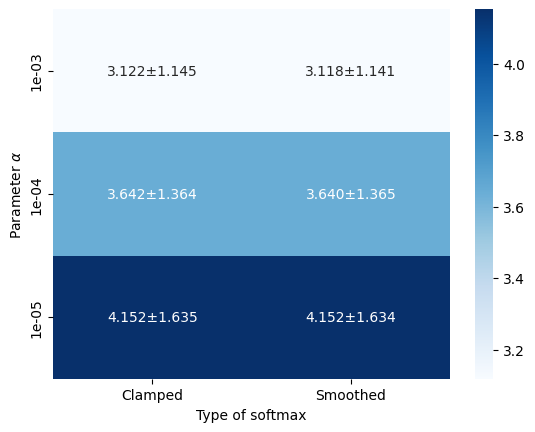

In [9]:
import seaborn as sn
if not zero_one_loss:
    idx = list(slicen(len(list(hps.keys()))))
    idx[0] = values_to_fetch.index(choosing_parameter)
    mean_array = np.zeros((len(hps['min_probability']), len(hps['clamp_method'])))
    object_array = np.empty((len(hps['min_probability']), len(hps['clamp_method'])), dtype=object)
    
    for i in range(len(hps['min_probability'])):
        for j in range(len(hps['clamp_method'])):
            idx[list(hps.keys()).index("min_probability")] = i
            idx[list(hps.keys()).index("clamp_method")] = j
            mean_array[i,j] = np.mean(results_matrix, axis=1)[tuple(idx)].mean()
            std_val = np.mean(results_matrix, axis=1)[tuple(idx)].std()
            object_array[i,j] = f"{mean_array[i,j]:.3f}±{std_val:.3f}"
    
    
    sn.heatmap(pd.DataFrame(mean_array, index=[f"{val:.0e}" for val in hps['min_probability']], columns=['Clamped', 'Smoothed']), annot=object_array, fmt="", cmap="Blues")
    plt.xlabel("Type of softmax")
    plt.ylabel(r"Parameter $\alpha$")
    plt.savefig(f"./results/ablation_bounded_CE_{dataset}.pdf")

In [10]:
if not zero_one_loss:
    idx = list(slicen(len(list(hps.keys()))))
    idx[0] = values_to_fetch.index(choosing_parameter)
    min_val = np.inf
    min_val_idx = 0
    for i in range(len(hps['min_probability'])):
        idx[list(hps.keys()).index("min_probability")] = i
        val_to_test = np.mean(results_matrix, axis=1)[tuple(idx)].mean()
        if val_to_test < min_val:
            min_val_idx = i
            min_val = val_to_test
    print(min_val, min_val_idx, hps['min_probability'][min_val_idx])

    idx = list(slicen(len(list(hps.keys()))+1))
    idx[list(hps.keys()).index("min_probability")+1] = min_val_idx
    results_matrix = results_matrix[tuple(idx)]

3.120428696293613 0 0.001


In [54]:
key_hps = [list(hps.keys())[0:list(hps.keys()).index("selection")]] + list(hps.keys())[2:]

In [55]:
if not zero_one_loss:
    one_or_not = 1 if dataset == "cifar10" else 0
        
    slices = slicen(list(hps.keys()).index('selection')+1) + (hps['selection'].index('Uniform'),) +\
            slicen(len(results_matrix.shape) - list(hps.keys()).index('selection')-2)
    uniform_results = copy.deepcopy(results_matrix[slices])
    
    key_hps = list(hps.keys())[0:list(hps.keys()).index("selection")] + list(hps.keys())[list(hps.keys()).index("selection")+1:]
    for vals in list(product(*(list(hps.values())[0:list(hps.keys()).index("selection")] + list(hps.values())[list(hps.keys()).index("selection")+1:]))):
        print(vals, slices)
        min_val_loss, max_val_loss = get_min_max_loss(hps['min_probability'][min_val_idx], dataset_configuration['n_classes'],
                                                vals[key_hps.index("clamp_method")])
        lambda_loss = max_val_loss - min_val_loss
    
        idx_vals = ()
        for i in range(len(vals)):
            if key_hps[i] == "min_probability":
                continue
            idx_vals = idx_vals +(hps[key_hps[i]].index(vals[i]), )
        print(idx_vals)
        complement_loss = uniform_results[(values_to_fetch.index('complement_loss'),) + idx_vals]
        
        normalized_loss = (complement_loss - min_val_loss) / lambda_loss
        complement_size = uniform_results[(values_to_fetch.index('train_set_size'),) + idx_vals] -\
                            uniform_results[(values_to_fetch.index('compression_set_size'),) + idx_vals]
        kl_bound = kl_inv(normalized_loss, np.log(1/dataset_configuration['delta'])/int(complement_size), "MAX")
        new_bound =  min_val_loss + lambda_loss * kl_bound
        print(new_bound, uniform_results[(values_to_fetch.index('CE_kl_bound'),) + idx_vals])
        assert new_bound <= uniform_results[(values_to_fetch.index('CE_kl_bound'),) + idx_vals]
    
        uniform_results[(values_to_fetch.index('CE_kl_bound'),) + idx_vals] = new_bound
        uniform_results[(values_to_fetch.index('full_disagreement_loss'),) + idx_vals] = new_bound + \
                                        uniform_results[(values_to_fetch.index("disagreement_loss_kl"),) + idx_vals]
        
    # END
    results_matrix[slices] = copy.deepcopy(uniform_results)

In [56]:
hp_list = list(hps.values())[1:]
params_product = list(product(*hp_list))
name_list = []

for params in params_product:
    if not zero_one_loss and params[list(hps.keys())[1:].index("min_probability")] != hps['min_probability'][min_val_idx]:
        continue
    name = ""
    for p in params:
        name += str(p) + " "
    name_list.append(name[:-1])

reshaped_matrix = np.mean(results_matrix, axis=1).reshape(results_matrix.shape[0],np.prod(results_matrix.shape[2:])).T
mean_df = pd.DataFrame(reshaped_matrix, index=name_list, columns=values_to_fetch)

In [57]:
reshaped_matrix_std = np.nanstd(results_matrix, axis=1).reshape(results_matrix.shape[0],np.prod(results_matrix.shape[2:])).T
std_df = pd.DataFrame(reshaped_matrix_std, index=name_list, columns=values_to_fetch)

/Users/mathieubazinet/Documents/PythonProjects/ncp2l/ncp2lEnv/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [58]:
results_mat_1 = np.zeros((2, len(hps['selection']), len(hps['fraction'])), dtype='object')

for selection_idx in range(len(hps['selection'])):
    for fraction_idx in range(len(hps['fraction'])):
        mean_mat = np.mean(results_matrix, axis=1)
        std_mat = np.nanstd(results_matrix, axis=1)
        slices = list(slicen(len(mean_mat.shape)))
        slices[0] = values_to_fetch.index(choosing_parameter)
        slices[list(hps.keys()).index("selection")] = selection_idx
        slices[list(hps.keys()).index("fraction")] = fraction_idx
        mat = mean_mat[tuple(slices)]
        mat_shape = mat.shape
        try:
            argmin = np.nanargmin(mat)
        except ValueError:
            argmin = np.argmin(mat)
        min_idx = np.unravel_index(argmin, mat_shape)
        if dataset == "mnist":
            full_idx = (min_idx[0], selection_idx, fraction_idx) + min_idx[1:]
        else:
            full_idx = (selection_idx, fraction_idx) + min_idx
        if zero_one_loss:
            temp = (f"%.2f" % round(100*mean_mat[(values_to_fetch.index("test_error"),) + full_idx],2)) + r"$\pm$"
            temp += (f"%.2f" % round(100*std_mat[(values_to_fetch.index("test_error"),) + full_idx],2))
            results_mat_1[0, selection_idx,fraction_idx] = temp
            
            if hps['selection'][selection_idx] == "Uniform":
                val_to_use = "full_disagreement_test_set"
            else:
                val_to_use = "full_disagreement_bound_brute_force"

            temp = (f"%.2f" % round(100*mean_mat[(values_to_fetch.index(val_to_use),) + full_idx],2)) + r"$\pm$"
            temp += (f"%.2f" % round(100*std_mat[(values_to_fetch.index(val_to_use),) + full_idx],2))
            results_mat_1[1, selection_idx,fraction_idx] = temp
        else:
            temp = (f"%.4f" % round(mean_mat[(values_to_fetch.index("test_loss"),) + full_idx],4)) + r"$\pm$"
            temp += (f"%.4f" % round(std_mat[(values_to_fetch.index("test_loss"),) + full_idx],4))
            results_mat_1[0, selection_idx,fraction_idx] = temp

            temp = (f"%.4f" % round(mean_mat[(values_to_fetch.index("full_disagreement_loss"),) + full_idx],4))+ r"$\pm$"
            temp += (f"%.4f" % round(std_mat[(values_to_fetch.index("full_disagreement_loss"),) + full_idx],4))
            results_mat_1[1, selection_idx,fraction_idx] = temp
            
if zero_one_loss:
    print(pd.DataFrame(np.concatenate((results_mat_1[0,:,:], results_mat_1[1,:,:]), axis=1), index=hps['selection']).to_latex())
else:
    print(pd.DataFrame(np.concatenate((results_mat_1[0,:,:], results_mat_1[1,:,:]), axis=1), index=hps['selection']).to_latex())

hps_coreset = hps

\begin{tabular}{lllllllllllllllllllll}
\toprule
 & 0 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9 & 10 & 11 & 12 & 13 & 14 & 15 & 16 & 17 & 18 & 19 \\
\midrule
Uniform & 78.35$\pm$2.48 & 68.16$\pm$2.16 & 62.31$\pm$1.40 & 39.87$\pm$1.07 & 26.09$\pm$1.68 & 19.97$\pm$0.73 & 16.23$\pm$0.42 & 12.33$\pm$0.25 & 10.44$\pm$0.17 & 8.84$\pm$0.20 & 158.89$\pm$4.94 & 137.62$\pm$4.31 & 126.10$\pm$2.76 & 79.91$\pm$2.13 & 51.93$\pm$3.34 & 39.50$\pm$1.40 & 32.02$\pm$0.46 & 24.35$\pm$0.63 & 20.12$\pm$0.16 & 17.37$\pm$0.27 \\
kCenterGreedy & 78.00$\pm$1.31 & 70.38$\pm$0.63 & 64.60$\pm$1.58 & 43.06$\pm$1.51 & 27.65$\pm$0.46 & 20.07$\pm$0.34 & 15.92$\pm$0.46 & 12.29$\pm$0.39 & 9.69$\pm$0.20 & 8.49$\pm$0.20 & 170.22$\pm$1.83 & 160.53$\pm$1.00 & 152.02$\pm$2.11 & 122.65$\pm$2.28 & 100.16$\pm$1.13 & 90.63$\pm$1.05 & 87.34$\pm$0.77 & 86.78$\pm$0.68 & 88.68$\pm$0.22 & 91.48$\pm$0.11 \\
Forgetting & 80.76$\pm$2.93 & 72.52$\pm$0.90 & 69.33$\pm$0.97 & 57.91$\pm$1.27 & 40.87$\pm$0.93 & 26.97$\pm$1.13 & 17.71$\pm$1.23 & 10.8

In [59]:
results_mat_2 = np.zeros((len(hps['selection']), 7), dtype="object")

list_indexs = [[] for _ in range(len(hps['selection']))]
for name in list(mean_df.index):
    for selection in hps['selection']:
        if selection in name:
            list_indexs[hps['selection'].index(selection)].append(name)
            break

for i in range(len(list_indexs)):
    if zero_one_loss and hps['selection'][i] == "Uniform":
        c_param = "full_disagreement_test_set"
    else:
        c_param = choosing_parameter
    best_datapoint = mean_df.loc[list_indexs[i]].sort_values(by=c_param).iloc[0,:]
    if "Uniform" in best_datapoint.name and zero_one_loss:
        list_of_vals = ['complement_error', 'test_error', 'best_model_complement_error', 'best_model_test_error', 'test_set_bound_brute', 'disagreement_brute_force', 'full_disagreement_test_set']
        mult_param = 100
        rounding = 2
    elif zero_one_loss:
        list_of_vals = ['complement_error', 'test_error', 'best_model_complement_error', 'best_model_test_error', 'binomial_approximation_shah','disagreement_brute_force', 'full_disagreement_bound_brute_force']
        mult_param = 100
        rounding = 2
    else:
        list_of_vals = ['complement_loss', 'test_loss', 'best_model_complement_loss', 'best_model_test_loss', 'CE_kl_bound', 'disagreement_loss_kl', 'full_disagreement_loss']
        mult_param = 1
        rounding = 4
        
    for j in range(len(list_of_vals)):
        elem = list_of_vals[j]
        best_std = std_df.loc[best_datapoint.name]
        results_mat_2[i,j] = (f"%.{rounding}f" % round(mult_param * best_datapoint[elem], rounding)) + r"$\pm$"
        results_mat_2[i,j] += (f"%.{rounding}f" % round(mult_param * best_std[elem], rounding))
    

if zero_one_loss:
    print(pd.DataFrame(results_mat_2, index=hps['selection']).to_latex(float_format="%.2f"))
else:
    print(pd.DataFrame(results_mat_2, index=hps['selection']).to_latex(float_format="%.4f"))

\begin{tabular}{llllllll}
\toprule
 & 0 & 1 & 2 & 3 & 4 & 5 & 6 \\
\midrule
Uniform & 8.53$\pm$0.12 & 9.00$\pm$0.17 & 0.00$\pm$0.00 & 5.84$\pm$0.16 & 9.02$\pm$0.12 & 8.34$\pm$0.12 & 17.36$\pm$0.20 \\
kCenterGreedy & 11.50$\pm$0.21 & 12.29$\pm$0.39 & 0.00$\pm$0.00 & 5.84$\pm$0.16 & 75.08$\pm$0.20 & 11.70$\pm$0.55 & 86.78$\pm$0.68 \\
Forgetting & 3.19$\pm$0.16 & 8.55$\pm$0.12 & 0.00$\pm$0.00 & 5.84$\pm$0.16 & 72.89$\pm$0.21 & 8.24$\pm$0.12 & 81.13$\pm$0.33 \\
DeepFool & 11.33$\pm$0.23 & 12.17$\pm$0.39 & 0.00$\pm$0.00 & 5.84$\pm$0.16 & 74.92$\pm$0.22 & 12.08$\pm$0.16 & 87.00$\pm$0.34 \\
\bottomrule
\end{tabular}



# P2L Results

In [60]:
if 'zero_one_loss' not in locals():
    zero_one_loss = False

if zero_one_loss:
    choosing_parameter = "full_disagreement_bound_p2l"
    # choosing_parameter = "validation_error"
    values_to_fetch = ['complement_error', 'validation_error', 'test_error', 'best_model_complement_error','best_model_test_error',
                       'p2l_bound', 'disagreement_brute_force', 'full_disagreement_bound_p2l', 'compression_set_size', 'train_set_size']
else:
    choosing_parameter = "full_disagreement_loss"
    # choosing_parameter = "validation_loss"
    values_to_fetch = ['complement_loss', 'validation_loss', 'test_loss', 'best_model_complement_loss', 'best_model_test_loss','CE_kl_bound',
                       'disagreement_loss_kl', 'full_disagreement_loss', 'compression_set_size', 'train_set_size']
    

In [ ]:
results_list = []
dataset_list = []

for dataset_ in ['mnist', 'cifar10']:
    dataset_config_name = "./configs/dataset_configs/" + dataset_ + ".yaml"
    with open(dataset_config_name) as file:
        dataset_configuration = yaml.safe_load(file)
    
    sweep_config_name = "./configs/experiment_configs/p2l/" + dataset_ + ".yaml"
    with open(sweep_config_name) as file:
        sweep_configuration = yaml.safe_load(file)
    
    hps = {}
    for key, item in sweep_configuration['parameters'].items():
        if item.get('values', None) is not None:
            hps[key] = correct_type_of_entry(item['values'])
    size_hyperparams = tuple([len(l) for l in hps.values()])
    
    results_mat_3 = np.ones(((len(values_to_fetch),) + size_hyperparams))
    results_mat_3[:] = np.nan
    
    for sweep_config in create_all_configs(sweep_configuration):
        file_name = get_exp_file_name(sweep_config|dataset_configuration, path="./experiment_logs/")
        if os.path.exists(file_name):
            with open(file_name) as f:
                config = json.load(f)
                for val_to_fetch_idx in range(len(values_to_fetch)):
                    matrix_idx = tuple([val_to_fetch_idx] + [hps[key].index(config['config'].get(key, None)) for key in hps.keys()])
                    val_to_fetch = values_to_fetch[val_to_fetch_idx]
                    results_mat_3[matrix_idx] = config.get(val_to_fetch, None)
                
                if zero_one_loss:
                    p2l_bound = config['p2l_bound']
                    comp_error = config['complement_error']
                    compression_set_size = config['compression_set_size']
                    n = config['train_set_size']
                    nb_of_error = int((n - compression_set_size) * comp_error)
    
                    output = {}
                    compute_all_p2l_bounds(compression_set_size, n, nb_of_error, config['config']['delta'], output, verbose=False)
                    assert config['p2l_bound'] < output['tighter_p2l_bound']
    
                    p2l_idx = tuple([values_to_fetch.index('p2l_bound')] +[hps[key].index(config['config'].get(key, None)) for key in hps.keys()])
                    results_mat_3[p2l_idx] = output['tighter_p2l_bound']
    
                    new_full_disagreement_bound = output['tighter_p2l_bound'] +  config['disagreement_brute_force']
                    full_bound_idx = tuple([values_to_fetch.index('full_disagreement_bound_p2l')] +[hps[key].index(config['config'].get(key, None)) for key in hps.keys()])
                    results_mat_3[full_bound_idx] = output['tighter_p2l_bound'] +  config['disagreement_brute_force']
                    assert config['full_disagreement_bound_p2l'] < results_mat_3[full_bound_idx]

    if not zero_one_loss:
        idx = list(slicen(len(results_mat_3.shape)))
        idx[list(hps.keys()).index("min_probability")+1] = min_val_idx
        results_mat_3 = results_mat_3[tuple(idx)]
        
    hp_list = list(hps.values())[1:]
    params_product = list(product(*hp_list))
    name_list = []
    for params in params_product:
        if not zero_one_loss and params[list(hps.keys())[1:].index("min_probability")] != hps['min_probability'][min_val_idx]:
            continue
        name = ""
        for p in params:
            name += str(p) + " "
        name_list.append(name[:-1])
    
    reshaped_matrix = np.mean(results_mat_3, axis=1).reshape(results_mat_3.shape[0],np.prod(results_mat_3.shape[2:])).T
    mean_df = pd.DataFrame(reshaped_matrix, index=name_list, columns=values_to_fetch)
    
    reshaped_matrix_std = np.nanstd(results_mat_3, axis=1).reshape(results_mat_3.shape[0],np.prod(results_mat_3.shape[2:])).T
    std_df = pd.DataFrame(reshaped_matrix_std, index=name_list, columns=values_to_fetch)
    
    if "model_type" in list(hps.keys()):
        list_indexs = [[] for _ in range(len(hps['model_type']))]
        for name in list(mean_df.index):
            for model_idx in range(len(hps['model_type'])):
                if hps['model_type'][model_idx] in name:
                    list_indexs[model_idx].append(name)
                    break
    else:
        list_indexs = [list(mean_df.index)]
    
    for i in range(len(list_indexs)):
        index_mean = mean_df.loc[list_indexs[i]].sort_values(by=choosing_parameter).index[0]
        
        best_datapoint_mean = mean_df.loc[index_mean]
        best_datapoint_std = std_df.loc[index_mean]
        
        if "model_type" in list(hps.keys()):
            if hps['model_type'][i] == "cnn":
                mt = "CNN"
            elif hps['model_type'][i] == "resnet":
                mt = "ResNet18"
            else:
                raise NotImplementedError
        else:
            mt = "CNN"
    
        rounding_val = 2 if zero_one_loss else 4
        rounding = f"%.{rounding_val}f"
        
        mult = 100.0 if zero_one_loss else 1.0
        
        cpr = (rounding % round(100*best_datapoint_mean['compression_set_size']/best_datapoint_mean['train_set_size'],rounding_val)) + r"$\pm$"
        cpr += (rounding % round(100*best_datapoint_std['compression_set_size']/best_datapoint_mean['train_set_size'],rounding_val))
    
        if zero_one_loss:
            vals_to_add = ["Model", 'complement_error', 'test_error', "cpr", 'best_model_complement_error', 'best_model_test_error',
                            'p2l_bound', 'disagreement_brute_force', 'full_disagreement_bound_p2l']
        else:
            vals_to_add = ["Model", 'complement_loss', 'test_loss', "cpr", 'best_model_complement_loss',
                           'best_model_test_loss', 'CE_kl_bound', 'disagreement_loss_kl', 'full_disagreement_loss']
    
        list_of_vals = []
        for val in vals_to_add:
            if val == "Model":
                list_of_vals.append(mt)
                continue
            elif val == "cpr":
                list_of_vals.append(cpr)
                continue
    
            temp = (rounding % round(mult*best_datapoint_mean[val],rounding_val)) + r"$\pm$"
            temp += (rounding % round(mult*best_datapoint_std[val], rounding_val))
            list_of_vals.append(temp)
    
        results_list.append(pd.Series(list_of_vals, index=vals_to_add))
            
        dataset_list.append(dataset_.upper())

if zero_one_loss:
    print(pd.DataFrame(results_list, index=dataset_list).to_latex(float_format="%.2f"))
else:
    print(pd.DataFrame(results_list, index=dataset_list).to_latex(float_format="%.4f"))

\begin{tabular}{llllllllll}
\toprule
 & Model & complement_error & test_error & cpr & best_model_complement_error & best_model_test_error & p2l_bound & disagreement_brute_force & full_disagreement_bound_p2l \\
\midrule
MNIST & CNN & 0.00$\pm$0.00 & 0.59$\pm$0.04 & 2.73$\pm$0.04 & 0.29$\pm$0.03 & 0.50$\pm$0.07 & 3.06$\pm$0.04 & 0.82$\pm$0.09 & 3.88$\pm$0.07 \\
CIFAR10 & CNN & 0.00$\pm$0.00 & 16.68$\pm$1.66 & 47.36$\pm$2.18 & 0.00$\pm$0.00 & 9.24$\pm$0.10 & 48.47$\pm$2.19 & 15.68$\pm$1.79 & 64.15$\pm$3.92 \\
CIFAR10 & ResNet18 & 0.00$\pm$0.00 & 6.88$\pm$0.10 & 49.28$\pm$2.78 & 0.00$\pm$0.00 & 5.84$\pm$0.16 & 50.39$\pm$2.78 & 6.74$\pm$0.16 & 57.13$\pm$2.71 \\
\bottomrule
\end{tabular}



# Plots

In [62]:
SMALL_SIZE = 13
MEDIUM_SIZE = 15
BIGGER_SIZE = 17

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

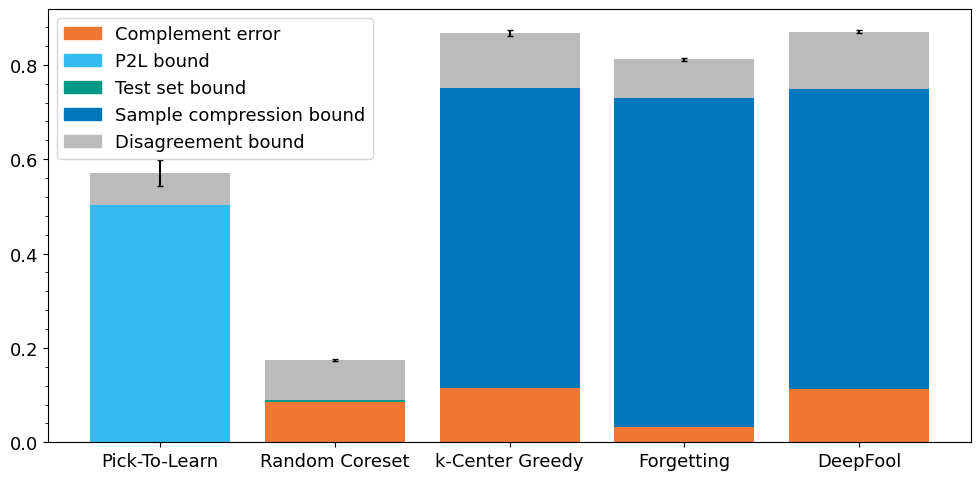

In [63]:
plt.style.use(['vibrant'])
plt.figure(figsize=(10,5))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [colors[0], colors[1], colors[6], colors[2], colors[5]]

x = []
up = []
bottom = []
yerr = []
all_color = []

x += ["Pick-To-Learn"] * 3

if dataset == "mnist":
    index = 0
else:
    if zero_one_loss:
        index = np.argmin(np.array([results_list[1]['full_disagreement_bound_p2l'],
                                    results_list[2]['full_disagreement_bound_p2l']
                                   ]
                                  )
                         )+1
    else:
        index = np.argmin(np.array([results_list[1]['disagreement_loss_kl'],
                            results_list[2]['disagreement_loss_kl']
                           ]
                          )
                 )+1
if zero_one_loss:
    s_up = list(results_list[index][['complement_error', 'p2l_bound', 'disagreement_brute_force']])
    s_up = [float(val[:val.find("$")])/100 for val in s_up]
    all_color += [colors[0], colors[3], colors[2]]
else:
    s_up = list(results_list[index][['complement_loss', 'CE_kl_bound', 'disagreement_loss_kl']])
    s_up = [float(val[:val.find("$")]) for val in s_up]
    all_color += colors[:3]
    
    
up += [ s_up[0], s_up[1]-s_up[0], s_up[2]]
bottom += [0, s_up[0], s_up[1]]

val = results_list[index].iloc[-1]
idx_1 = val.find("$") + 1
idx_2 = val[idx_1:].find("$") + 1
error_bar = float(val[idx_1 + idx_2:])
if zero_one_loss:
    error_bar /= 100
yerr += [np.nan, np.nan, error_bar]

name_dict = {'Uniform':'Random Coreset', 'kCenterGreedy':'k-Center Greedy', 'Uncertainty':'Margin',
             'Forgetting':'Forgetting', 'DeepFool':'DeepFool', 'Submodular':'GraphCut'}

for s in range(len(selection_list)):
    x += [name_dict[selection_list[s]]]*3
    s_up = []
    for i in [0, 4, 5]:
        val = results_mat_2[s,i]
        new_val = float(val[:val.find("$")])
        if zero_one_loss:
            new_val /= 100
        s_up.append(new_val)
    up += [s_up[0], s_up[1] - s_up[0], s_up[2]]
    bottom += [0, s_up[0], s_up[1]]

    val = results_mat_2[s,-1]
    idx_1 = val.find("$") + 1
    idx_2 = val[idx_1:].find("$") + 1
    error_bar = float(val[idx_1 + idx_2:])
    if zero_one_loss:
        error_bar /= 100
    yerr += [np.nan, np.nan, error_bar]
    if selection_list[s] == "Uniform":
        all_color += [colors[0], colors[4], colors[2]]
    else:
        all_color += colors[:3]
    
plt.bar(x, up, bottom=bottom, color=all_color, yerr=yerr, capsize=2)

if not zero_one_loss and dataset == "cifar10":
    _, max_val_clamp = get_min_max_loss(hps['min_probability'][min_val_idx], 10, "clamp")
    plt.axhline(y=max_val_clamp, linestyle="--", color="black", label="Maximum value")

ax = plt.gca()
ax_handles, ax_labels = ax.get_legend_handles_labels()

name_val = 'Complement error' if zero_one_loss else "Complement loss"
if zero_one_loss:
    colors = {'Complement error':colors[0],'P2L bound':colors[3], 'Test set bound':colors[4],
              'Sample compression bound':colors[1], 'Disagreement bound':colors[2]}  
else:
    colors = {'Complement loss':colors[0], 'Sample compression bound':colors[1], 'Chernoff test set bound':colors[4],'Disagreement bound':colors[2]}  
labels = list(colors.keys())
handles = [plt.Rectangle((0,0),1,1, color=colors[label]) for label in labels]
plt.legend(ax_handles + handles, ax_labels + labels)

minor_locator = AutoMinorLocator(5) 
ax.yaxis.set_minor_locator(minor_locator)

plt.tight_layout()
plt.savefig(f"./results/barplot_{dataset}_{'risk' if zero_one_loss else 'loss'}.pdf")

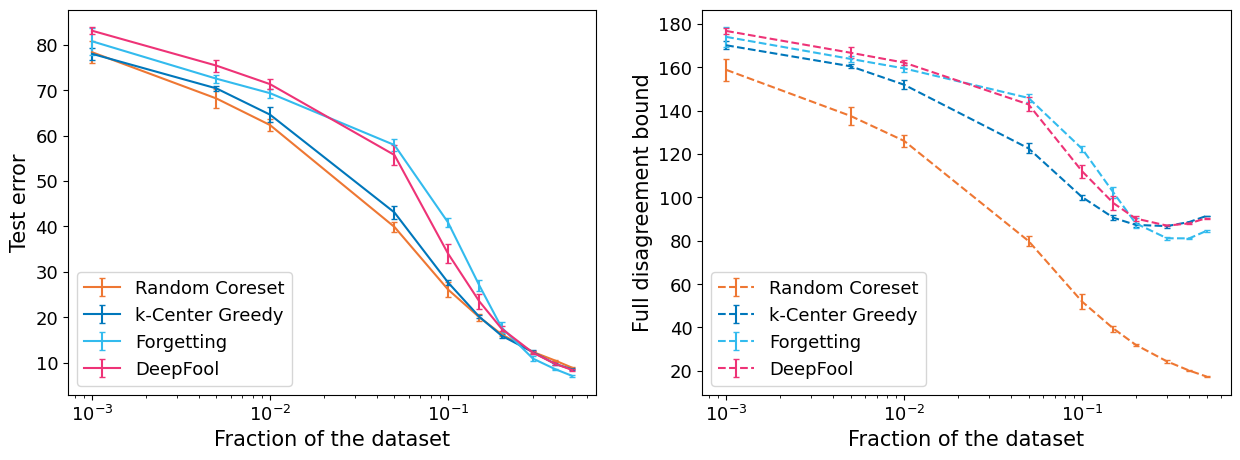

In [64]:
if zero_one_loss:
    plt.style.use(['vibrant'])
    name_dict = {'Uniform':'Random Coreset', 'kCenterGreedy':'k-Center Greedy', 'Uncertainty':'Margin',
                 'Forgetting':'Forgetting', 'DeepFool':'DeepFool', 'Submodular':'GraphCut'}
    
    fig, ax = plt.subplots(1,2, figsize=(15, 5))
    for i in range(results_mat_1.shape[0]):
        for j in range(results_mat_1.shape[1]):
            val_list = list(results_mat_1[i,j,:])
            mean_val_list = []
            std_val_list = []
            for val in val_list:
                mean_val_list.append(float(val[:val.find("$")]))
                std_val_list.append(float(val[val.rfind("$")+1:]))
            ax[i].errorbar(hps_coreset['fraction'], mean_val_list, yerr=std_val_list, capsize=2,
                         label=name_dict[selection_list[j]], linestyle="-" if i == 0 else "--")
    ax[0].semilogx()
    ax[0].set_ylabel("Test error")
    ax[0].set_xlabel("Fraction of the dataset")
    ax[1].semilogx()
    ax[1].set_ylabel("Full disagreement bound")
    ax[1].set_xlabel("Fraction of the dataset")
    ax[0].legend()
    ax[1].legend()
    plt.savefig(f"./results/coreset_try_{dataset}_compression_set_size.pdf")